In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('~/Downloads/games.csv')

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [7]:
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')	

In [8]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

In [9]:
df['year_of_release'] = df['year_of_release'].astype('Int64')

In [10]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [11]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
total_sales           0
dtype: int64

In [14]:
df['year_of_release'].value_counts().sort_index()

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: Int64

Mira cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las viejas en desaparecer?

In [15]:
df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

Construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las viejas en desaparecer?

In [16]:
top_consolas = ['PS2', 'X360', 'PS3', 'Wii', 'DS']
df_top = df[df['platform'].isin(top_consolas)]

df_top.pivot_table(index= 'year_of_release', columns='platform', values='total_sales', aggfunc='sum')

platform,DS,PS2,PS3,Wii,X360
year_of_release,,,,,
1985,0.02,NaN,NaN,NaN,NaN
2000,NaN,39.17,NaN,NaN,NaN
2001,NaN,166.43,NaN,NaN,NaN
2002,NaN,205.38,NaN,NaN,NaN
2003,NaN,184.31,NaN,NaN,NaN
2004,17.27,211.81,NaN,NaN,NaN
2005,130.14,160.66,NaN,NaN,8.25
2006,119.81,103.42,20.96,137.15,51.62
2007,146.94,75.99,73.19,152.77,95.41


A partir de la distribución anual de las plataformas más vendidas, se observa que las consolas líderes tienen un ciclo de vida promedio de entre 10 y 11 años desde que aparecen en el mercado hasta que sus ventas caen a cero. El pico de popularidad y ventas máximas se alcanza generalmente a la mitad de su vida útil (entre el año 4 y 6 desde su lanzamiento).

In [17]:
df_relevante = df[df['year_of_release'] >= 2013]
df_relevante['year_of_release'].unique()

<IntegerArray>
[2013, 2015, 2014, 2016]
Length: 4, dtype: Int64

In [18]:
df_relevante.shape

(2233, 12)

In [19]:
df_relevante.pivot_table(index='year_of_release', columns= 'platform', values= 'total_sales', aggfunc= 'sum')

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,
2013,56.57,1.54,12.38,113.25,25.99,3.14,10.59,8.59,21.65,88.58,18.96
2014,43.76,NaN,13.28,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
2015,27.78,NaN,8.52,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14
2016,15.14,NaN,5.25,3.60,69.25,NaN,4.25,0.18,4.60,1.52,26.15


<Axes: title={'center': 'total_sales'}, xlabel='platform'>

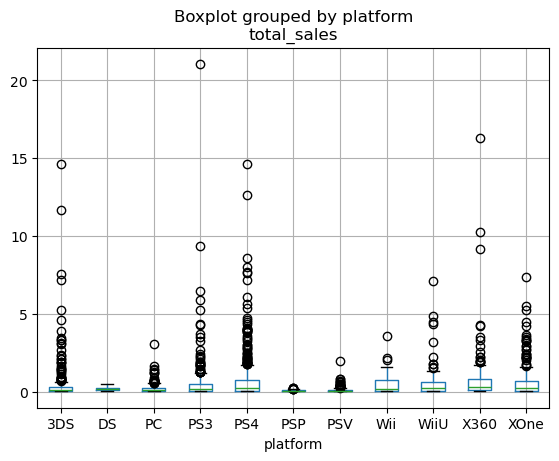

In [20]:
df_relevante.boxplot(column= 'total_sales', by='platform')

In [21]:
df_ps4 = df_relevante[df_relevante['platform'] == 'PS4']

<Axes: xlabel='critic_score', ylabel='total_sales'>

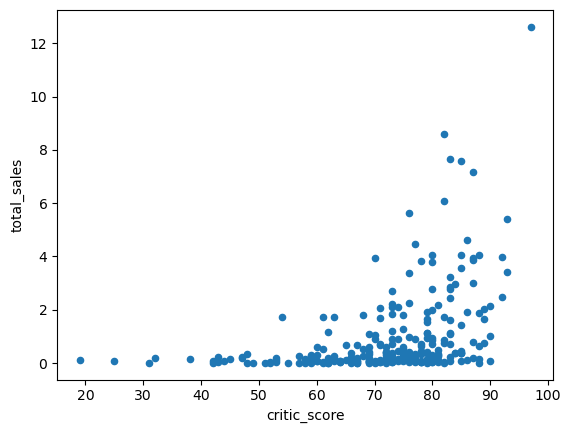

In [22]:
df_ps4.plot(kind='scatter', x='critic_score', y='total_sales')

In [23]:
df_ps4['critic_score'].corr(df_ps4['total_sales'])

np.float64(0.40656790206178095)

<Axes: xlabel='user_score', ylabel='total_sales'>

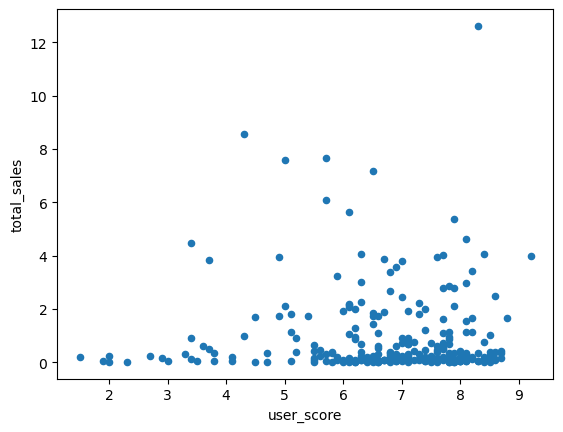

In [24]:
df_ps4.plot(kind='scatter', x='user_score', y='total_sales')

In [25]:
df_ps4['user_score'].corr(df_ps4['total_sales'])

np.float64(-0.031957110204556376)

Guía de Orientación Analítica (Para construir tu veredicto)
Para entender qué nos dice ese -0.03, compáralo con el 0.4065 que obtuviste en la celda de los críticos especializados. Piensa en estas tres pautas lógicas:

	1.	La cercanía al Cero absoluto: Un valor de -0.03 está prácticamente pegado al 0. En estadística, cualquier correlación que ronde el cero significa que no existe una relación lineal entre las dos variables.
	2.	El contraste de opiniones: * Los críticos profesionales (0.41) muestran una influencia moderada-positiva (el mercado se mueve un poco hacia donde apuntan los medios).
    
•	Los usuarios comunes (-0.03) muestran que su puntaje no tiene un impacto real en si un juego vende millones o no.

	3.	La psicología del consumidor: Piensa como psicólogo o como consumidor de tecnología: ¿Por qué un juego de PS4 con malas reseñas de la gente (un 5 o 6) puede vender 8 millones de copias? A veces el peso de una franquicia famosa, una campaña publicitaria gigantesca, o las ganas de jugar con amigos el día del estreno importan más que la calificación que la comunidad deje en internet semanas después.

In [26]:
df_xone = df_relevante[df_relevante['platform'] == 'XOne']

In [27]:
df_xone['user_score'].corr(df_xone['total_sales'])

np.float64(-0.06892505328279414)

Orientación para tu Respuesta de Negocio (Paso 3.7)
El proyecto te pide comparar estos hallazgos con otras plataformas para ver si el comportamiento es similar. Al mirar tus datos, tienes dos piezas de evidencia brutales:

•	PS4 (Usuarios): -0.0319
•	Xbox One (Usuarios): -0.0689

Para redactar tu conclusión, analiza lo siguiente:

	1.	Ambos números están sumamente cerca del 0, lo que significa que en las dos consolas principales de esta generación ocurre exactamente el mismo fenómeno: las calificaciones de los usuarios no están conectadas con el éxito comercial de los juegos.
    
	2.	Para que tu análisis quede impecable y súper completo antes de avanzar, valdría la pena calcular rápido la correlación de la Xbox One pero con los críticos (critic_score), solo para comprobar si ahí también da un número positivo moderado (alrededor de 0.40) como pasó en PlayStation.

In [28]:
ventas_genero = df_relevante.groupby('genre')['total_sales'].sum()

In [29]:
ventas_genero.sort_values(ascending=False)

genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

In [30]:
df_relevante.groupby('genre')['total_sales'].median().sort_values(ascending=False)

genre
Shooter         0.450
Sports          0.240
Platform        0.225
Role-Playing    0.125
Fighting        0.125
Racing          0.120
Action          0.110
Simulation      0.100
Misc            0.100
Strategy        0.080
Puzzle          0.060
Adventure       0.030
Name: total_sales, dtype: float64

•	Ventas Altas por Consistencia: Explica cómo géneros como Shooter o Sports (0.240) mantienen un rendimiento alto por juego individual, lo que los vuelve apuestas muy seguras en la industria.

•	Ventas Bajas Históricas: Identifica qué géneros están en el fondo en ambos lados (mira los números de Adventure o Puzzle tanto en suma como en mediana). Son géneros de nicho que no mueven grandes masas de dinero en esta era moderna.

In [31]:
df_relevante.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)

platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

In [32]:
df_relevante.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)

platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

In [33]:
df_relevante.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64

In [34]:
df_relevante.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

In [35]:
df_relevante.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

In [36]:
df_relevante.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64

In [37]:
df_relevante.groupby('rating')['na_sales'].sum().sort_values(ascending=False).head()

rating
M       165.21
E        79.05
E10+     54.24
T        49.79
Name: na_sales, dtype: float64

In [38]:
df_relevante.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).head()

rating
M       145.32
E        83.36
E10+     42.69
T        41.95
Name: eu_sales, dtype: float64

In [39]:
df_relevante.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).head()

rating
T       20.59
E       15.14
M       14.11
E10+     5.89
Name: jp_sales, dtype: float64

Introducción y Diagnóstico Global

Tras segmentar y analizar las ventas de la era moderna del mercado de videojuegos, se identificó un patrón de consumo sumamente claro:
mientras que Norteamérica (NA) y Europa (EU) comparten un comportamiento de compra casi idéntico, el mercado de Japón (JP) opera bajo una dinámica cultural y comercial completamente opuesta. Esta discrepancia se divide en tres pilares estratégicos:

1. Preferencia de Plataformas (Consolas)
•	Occidente (NA/EU): El consumidor occidental prioriza las consolas de sobremesa potentes de sala de estar. La PS4 lidera de manera contundente en ambas regiones (‭‬M en NA y ‭‬M en EU), seguida de cerca por la familia Xbox (XOne y X360) y la generación previa de Sony (PS3). Cabe destacar que Microsoft muestra un mejor desempeño "en casa" (Norteamérica) ocupando el segundo lugar, a diferencia de Europa donde pierde terreno frente a Sony.
•	Japón: El mercado del país asiático rompe el esquema tradicional al coronar a una consola portátil, la Nintendo 3DS, como la reina absoluta del mercado (‭‬M). Consolas portátiles como la PS Vita (PSV) entran con fuerza en el Top 3 (‭‬M), mientras que la PS4 se ve desplazada al cuarto puesto con apenas ‭‬M. Esto denota una clara preferencia por el juego en movimiento (on-the-go), adaptado al estilo de vida y movilidad urbana japonesa.
2. Distribución de Géneros Favoritos
•	Occidente (NA/EU): El Top 4 de géneros se replica a la perfección en ambas regiones: Action, Shooter, Sports y Role-Playing. Existe una fuerte inclinación hacia experiencias occidentales de acción directa, adrenalina y deportes competitivos.
•	Japón: El género rey indiscutible es el Role-Playing (RPG) con ‭‬M, superando por un margen notable a la acción (‭‬M). Los videojuegos de disparos (Shooter), que son pilares multimillonarios en Occidente, caen drásticamente en Japón al último lugar del Top 5 con apenas ‭‬M, confirmando que mecánicas de juego de corte más narrativo y estratégico tienen mayor arraigo cultural.
3. Impacto de la Clasificación ESRB
•	Occidente (NA/EU): La clasificación "M" (Mature / Mayores de 17 años) domina ampliamente el volumen de ingresos (‭‬M en NA y ‭‬M en EU), seguida por la clasificación "E" (Everyone / Todo Público). Esto guarda una correlación directa con el éxito de los géneros de Acción y Shooters en estas regiones.
•	Japón: Los títulos clasificados como "T" (Teen / Adolescentes) lideran la tabla de recaudación (‭‬M), relegando a la clasificación "M" al tercer puesto (‭‬M).
•	Nota metodológica sobre los datos: Es fundamental señalar que las ventas registradas bajo ESRB para Japón muestran un volumen menor en comparación con Occidente. Esto ocurre debido a un sesgo en los datos: la ESRB es un organismo puramente norteamericano. Muchos videojuegos desarrollados y consumidos de forma local en Japón son regulados bajo su propio sistema nacional (CERO). Los registros que aparecen aquí corresponden únicamente a los títulos que fueron adaptados y exportados para el mercado americano, lo que explica la aparente baja en la cifra total.
Conclusión Estratégica de Negocio
Para optimizar las campañas de marketing y la distribución de inventario de la tienda en el próximo año, las decisiones de inversión deben estar estrictamente segmentadas:
•	Un lanzamiento enfocado en Occidente requiere apostar fuertemente por títulos AAA de acción o disparos para consolas como PS4 o Xbox One.
•	Un lanzamiento enfocado en Japón debe canalizar los recursos hacia títulos de Rol (RPG), priorizando el ecosistema de consolas portátiles (Nintendo / PS Vita) y enfoques aptos para audiencias más jóvenes o generales.

In [40]:
def limpiar_mis_calificaciones(df, columna): 
    mi_reporte = {
        'Nulos': df[columna].isna().sum(),
        'Valores TBD': (df[columna] == 'tbd').sum()
    }

    for llave, valor in mi_reporte.items():
        print(f"{llave}: {valor}")
    
    df[columna] = np.where(df[columna] == 'tbd', np.nan, df[columna])
    df[columna] = df[columna].astype(float)
    valores_limpios = df[columna].dropna()

    return valores_limpios

In [41]:
limpiar_mis_calificaciones(df_relevante, 'user_score')

Nulos: 1041
Valores TBD: 0


16       8.2
23       8.1
42       8.3
60       2.6
69       2.6
        ... 
16643    6.6
16652    8.5
16654    5.1
16660    6.7
16692    7.6
Name: user_score, Length: 1192, dtype: float64

In [42]:
limpiar_mis_calificaciones(df_relevante, 'critic_score')

Nulos: 1242
Valores TBD: 0


16       97.0
23       97.0
42       97.0
60       73.0
69       71.0
         ... 
16597    65.0
16630    63.0
16652    81.0
16660    74.0
16692    80.0
Name: critic_score, Length: 991, dtype: float64

In [43]:

user_score_limpio = limpiar_mis_calificaciones(df_relevante, 'user_score')
critic_score_limpio = limpiar_mis_calificaciones(df_relevante, 'critic_score')

Nulos: 1041
Valores TBD: 0
Nulos: 1242
Valores TBD: 0


In [44]:
print("Nulos en score de usuario purificado:", user_score_limpio.isna().sum())
print("Tipo de dato final:", user_score_limpio.dtype)

Nulos en score de usuario purificado: 0
Tipo de dato final: float64


In [45]:
calif_xbox = limpiar_mis_calificaciones(df_relevante[df_relevante['platform'] == 'XOne'], 'user_score')

Nulos: 65
Valores TBD: 0


In [46]:
calif_pc = limpiar_mis_calificaciones(df_relevante[df_relevante['platform'] == 'PC'], 'user_score')

Nulos: 34
Valores TBD: 0


In [47]:
alpha = 0.05

valores_prueba = st.ttest_ind(calif_xbox, calif_pc, equal_var=False)

mi_p_value = valores_prueba.pvalue
print("El p-value obtenido es:", mi_p_value)

if mi_p_value < alpha:
    print("Rechazamos H0: Existe una diferencia estadísticamente significativa.")
else:
    print("No podemos rechazar la H0: No hay evidencia suficiente para decir que son diferentes.")

El p-value obtenido es: 0.14759594013430466
No podemos rechazar la H0: No hay evidencia suficiente para decir que son diferentes.


## Prueba de Hipótesis 1: Xbox One vs. PC

•	Hipótesis Nula (‭‬): El promedio de las calificaciones de los usuarios para las plataformas Xbox One y PC es el mismo.

•	Hipótesis Alternativa (‭‬): El promedio de las calificaciones de los usuarios para las plataformas Xbox One y PC es diferente.
Interpretación de Resultados:
Al ejecutar la prueba T de Student para muestras independientes (ajustada por varianzas desiguales mediante la prueba de Welch), obtuvimos un valor p (p-value) de aproximadamente 0.1476.
Dado que este valor p es considerablemente mayor que nuestro nivel de significancia alfa establecido (‭‬‭‬), no contamos con evidencia estadística suficiente para rechazar la hipótesis nula (‭‬).

Conclusión de Negocio:
Esto significa que la diferencia observada entre los promedios de calificación de ambas plataformas no es estadísticamente significativa y puede atribuirse al azar. Para fines prácticos y estratégicos de la tienda, los usuarios de Xbox One y los de PC evalúan los videojuegos de manera similar. No se justifica realizar estrategias de segmentación de productos o campañas de marketing basadas en la suposición de que una comunidad es más exigente o califica mejor que la otra.

In [48]:
calif_accion = limpiar_mis_calificaciones(df_relevante[df_relevante['genre'] == 'Action'], 'user_score')

Nulos: 377
Valores TBD: 0


In [49]:
calif_deportes = limpiar_mis_calificaciones(df_relevante[df_relevante['genre'] == 'Sports'], 'user_score')

Nulos: 54
Valores TBD: 0


In [50]:
alpha = 0.05

resultados_genero = st.ttest_ind(calif_accion, calif_deportes, equal_var=False)

mi_pvalue1 = resultados_genero.pvalue
print("El resultado p-value es:", mi_pvalue1)

if mi_pvalue1 < alpha:
    print("Se rechaza la H0 (las calificaciones son diferentes)")
else:
    print("No se puede rechazar la H0 (las calificaciones son estadísticamente iguales")

El resultado p-value es: 1.4460039700704315e-20
Se rechaza la H0 (las calificaciones son diferentes)


## Prueba de Hipótesis 2: Géneros de Acción vs. Deportes

•	Hipótesis Nula (‭‬): El promedio de las calificaciones de los usuarios para los géneros de Acción y Deportes es el mismo.

•	Hipótesis Alternativa (‭‬): El promedio de las calificaciones de los usuarios para los géneros de Acción y Deportes es diferente.

### Interpretación de Resultados:

Al realizar la prueba T de Student para muestras independientes (Prueba de Welch), obtuvimos un valor p (p-value) de ‭‬‭‬.
Dado que este valor es extremadamente menor que nuestro nivel de significancia alfa establecido (‭‬‭‬), contamos con evidencia estadística contundente para rechazar la hipótesis nula (‭‬). Esto demuestra que la diferencia en los promedios de calificación no se debe al azar.

### Conclusión de Negocio:

A diferencia de lo que vimos al comparar plataformas, aquí el género sí es un factor determinante en la percepción del usuario. Los videojugadores califican de manera drásticamente diferente los títulos de Acción en comparación con los de Deportes.
Para la toma de decisiones comerciales, esto implica que las comunidades tienen niveles de exigencia, expectativas y comportamientos de evaluación completamente distintos. La tienda o distribuidora no debe tratar estos catálogos bajo la misma estrategia de promoción; los juegos de deportes (que suelen tener lanzamientos anuales) y los de acción requieren campañas de fidelización y análisis de satisfacción totalmente segmentados.

In [51]:
print("Promedio Acción:", calif_accion.mean())
print("Promedio Deportes:", calif_deportes.mean())

Promedio Acción: 6.837532133676092
Promedio Deportes: 5.238124999999999
